In [1]:
import pandas as pd

In [3]:
cars = pd.read_csv("../data/used_cars_cleaned.csv")

In [7]:
cars

,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,make
0,0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi
...,...,...,...,...,...,...,...,...,...,...,...
97141,97141,Eos,2012,5990,Manual,74000,Diesel,125,58.9,2.0,Volkswagen
97142,97142,Fox,2008,1799,Manual,88102,Petrol,145,46.3,1.2,Volkswagen
97143,97143,Fox,2009,1590,Manual,70000,Petrol,200,42.0,1.4,Volkswagen
97144,97144,Fox,2006,1250,Manual,82704,Petrol,150,46.3,1.2,Volkswagen


In [5]:
cars = cars.drop(columns="Unnamed: 0")

In [7]:
X = cars.drop(columns="price")
y = cars["price"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
categorical_features = [
    "make",
    "model",
    "transmission",
    "fuelType"
]

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [15]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

from sklearn.pipeline import Pipeline

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", linear_model)
])

linear_pipeline.fit(X_train, y_train)

C:\Users\rgupt\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['make', 'model',
                                                   'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [17]:
linear_pred = linear_pipeline.predict(X_test)

linear_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": linear_pred
})

print(linear_results.head(10))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = mean_squared_error(y_test, linear_pred) ** 0.5
linear_r2 = r2_score(y_test, linear_pred)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

       Actual Price  Predicted Price
54212         29990     28550.839599
10990         18998     19496.848288
84183         14395     15727.760544
89508         14295     13597.374212
83349         10995     12248.663315
45145         15250     13815.974167
74452         10262     10318.166573
32677          9599     10195.751359
69457          6798      7140.361351
75457          5984      4999.513310
MAE: 2840.0490280433264
RMSE: 4681.823180524943
R²: 0.7765836441868843


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
   random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [58]:
rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": rf_pred
})

rf_results.head(10)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 1135.7745649836008
RMSE: 1991.6088691529385
R²: 0.9595709951142684


In [19]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [ ]:
xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": xgb_pred
})

xgb_results.head(20)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

In [29]:
import time
from sklearn.model_selection import cross_val_score

# Random Forest
start = time.time()

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

rf_time = time.time() - start

# XGBoost
start = time.time()

xgb_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

xgb_time = time.time() - start


# Results
print("Random Forest CV MAE:", -rf_scores.mean())
print(f"Random Forest time: {rf_time / 60:.1f} minutes")

print("XGBoost CV MAE:", -xgb_scores.mean())
print(f"XGBoost time: {xgb_time / 60:.1f} minutes")

Random Forest CV MAE: 1175.9179704347698
Random Forest time: 13.6 minutes
XGBoost CV MAE: 1325.4415125556018
XGBoost time: 0.0 minutes


In [37]:
print(rf_scores)
print(xgb_scores)

[-1172.39750788 -1162.74466211 -1169.03214193 -1187.30424111
 -1188.11129914]
[-1325.67786751 -1297.42950683 -1345.81089751 -1342.45829556
 -1315.83099537]


### Cross-Validation Model Comparison

To obtain a more reliable comparison between the Random Forest and XGBoost models, **5-fold cross-validation** was performed on the training data using **Mean Absolute Error (MAE)** as the evaluation metric.

| Model | Cross-Validation MAE | Time |
|---|---:|---:|
| Random Forest | £1,175.92 | 13.6 minutes |
| XGBoost | £1,325.44 | < 0.1 minutes |

The **Random Forest achieved the lower cross-validation MAE**, with predictions approximately **£1,176 away from the actual vehicle price on average**, compared with approximately **£1,325 for XGBoost**.

This represents an improvement of approximately **£150 per prediction**, suggesting that Random Forest is currently the stronger-performing baseline model.

However, XGBoost completed the cross-validation substantially faster. Both models will therefore be considered for **hyperparameter tuning** before selecting the final model for evaluation on the unseen test data.

In [41]:
from sklearn.model_selection import RandomizedSearchCV
import time

xgb_param_grid = {
    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7, 10],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

start = time.time()

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

xgb_tuning_time = time.time() - start

print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

print("\nBest XGBoost CV MAE:")
print(-xgb_random_search.best_score_)

print(f"\nTuning time: {xgb_tuning_time / 60:.1f} minutes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}

Best XGBoost CV MAE:
1106.2928198479285

Tuning time: 2.0 minutes


In [43]:
from sklearn.model_selection import RandomizedSearchCV
import time

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

start = time.time()

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=6,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_random_search.fit(X_train, y_train)

rf_tuning_time = time.time() - start

print("\nBest Random Forest parameters:")
print(rf_random_search.best_params_)

print("\nBest Random Forest CV MAE:")
print(-rf_random_search.best_score_)

print(f"\nTuning time: {rf_tuning_time / 60:.1f} minutes")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Random Forest parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 20}

Best Random Forest CV MAE:
1222.927588520697

Tuning time: 19.1 minutes


In [45]:
from sklearn.model_selection import cross_val_score
import numpy as np
import time

# Original Random Forest
start = time.time()

rf_original_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

rf_original_time = time.time() - start


# Tuned Random Forest
start = time.time()

rf_tuned_scores = cross_val_score(
    rf_random_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

rf_tuned_time = time.time() - start


# Tuned XGBoost
start = time.time()

xgb_tuned_scores = cross_val_score(
    xgb_random_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

xgb_tuned_time = time.time() - start


print(f"Original RF MAE: £{-rf_original_scores.mean():.2f}")
print(f"Tuned RF MAE:    £{-rf_tuned_scores.mean():.2f}")
print(f"Tuned XGB MAE:   £{-xgb_tuned_scores.mean():.2f}")

print()
print(f"Original RF SD: £{rf_original_scores.std():.2f}")
print(f"Tuned RF SD:    £{rf_tuned_scores.std():.2f}")
print(f"Tuned XGB SD:   £{xgb_tuned_scores.std():.2f}")

Original RF MAE: £1175.92
Tuned RF MAE:    £1207.23
Tuned XGB MAE:   £1106.29

Original RF SD: £10.12
Tuned RF SD:    £12.87
Tuned XGB SD:   £11.17


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Best tuned XGBoost model
final_model = xgb_random_search.best_estimator_

# Make predictions on the untouched test set
y_pred = final_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final Test MAE:  £{mae:.2f}")
print(f"Final Test RMSE: £{rmse:.2f}")
print(f"Final Test R²:   {r2:.4f}")

Final Test MAE:  £1079.17
Final Test RMSE: £1824.37
Final Test R²:   0.9661


In [51]:
xgb_param_grid_2 = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__learning_rate": [0.05, 0.075, 0.1, 0.125],
    "model__max_depth": [8, 10, 12, 15],
    "model__min_child_weight": [2, 3, 4],
    "model__subsample": [0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8]
}

In [53]:
import time
from sklearn.model_selection import RandomizedSearchCV

start = time.time()

xgb_random_search_2 = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid_2,
    n_iter=30,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_search_2.fit(X_train, y_train)

xgb_tuning_time_2 = time.time() - start

print("Best XGBoost parameters:")
print(xgb_random_search_2.best_params_)

print(f"\nBest XGBoost CV MAE: £{-xgb_random_search_2.best_score_:.2f}")

print(f"\nTuning time: {xgb_tuning_time_2 / 60:.1f} minutes")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 15, 'model__learning_rate': 0.075, 'model__colsample_bytree': 0.7}

Best XGBoost CV MAE: £1071.30

Tuning time: 6.8 minutes


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select the best tuned XGBoost model
final_model = xgb_random_search_2.best_estimator_

# Make predictions on the untouched test set
y_pred = final_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Final Test MAE:  £{mae:.2f}")
print(f"Final Test RMSE: £{rmse:.2f}")
print(f"Final Test R²:   {r2:.4f}")

Final Test MAE:  £1034.44
Final Test RMSE: £1835.11
Final Test R²:   0.9657


In [57]:
import pandas as pd

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results["Error"] = results["Predicted Price"] - results["Actual Price"]
results["Absolute Error"] = abs(results["Error"])

results.head(20)

,Actual Price,Predicted Price,Error,Absolute Error
54212,29990,35686.441406,5696.441406,5696.441406
10990,18998,19338.380859,340.380859,340.380859
84183,14395,14646.566406,251.566406,251.566406
89508,14295,13166.442383,-1128.557617,1128.557617
83349,10995,11953.547852,958.547852,958.547852
45145,15250,15090.711914,-159.288086,159.288086
74452,10262,9342.683594,-919.316406,919.316406
32677,9599,9708.194336,109.194336,109.194336
69457,6798,6882.436035,84.436035,84.436035
75457,5984,6051.142090,67.142090,67.142090


In [59]:
results = X_test.copy()

results["Actual Price"] = y_test
results["Predicted Price"] = y_pred
results["Error"] = results["Predicted Price"] - results["Actual Price"]
results["Absolute Error"] = abs(results["Error"])

results.head(20)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,make,Actual Price,Predicted Price,Error,Absolute Error
54212,V Class,2019,Automatic,9000,Diesel,145,38.7,2.0,Mercedes,29990,35686.441406,5696.441406,5696.441406
10990,X1,2016,Semi-Auto,24347,Diesel,150,55.4,2.0,BMW,18998,19338.380859,340.380859,340.380859
84183,Golf,2017,Semi-Auto,21162,Petrol,145,55.4,1.4,Volkswagen,14395,14646.566406,251.566406,251.566406
89508,Polo,2019,Manual,14533,Petrol,145,52.3,1.0,Volkswagen,14295,13166.442383,-1128.557617,1128.557617
83349,Golf,2016,Manual,34258,Petrol,30,53.3,1.4,Volkswagen,10995,11953.547852,958.547852,958.547852
45145,CL Class,2014,Manual,28612,Diesel,30,64.2,1.8,Mercedes,15250,15090.711914,-159.288086,159.288086
74452,Astra,2016,Manual,30079,Petrol,160,46.3,1.6,Vauxhall,10262,9342.683594,-919.316406,919.316406
32677,Fiesta,2017,Manual,18593,Petrol,0,65.7,1.0,Ford,9599,9708.194336,109.194336,109.194336
69457,Corsa,2016,Manual,34115,Petrol,30,55.4,1.4,Vauxhall,6798,6882.436035,84.436035,84.436035
75457,Viva,2016,Manual,18834,Petrol,20,62.8,1.0,Vauxhall,5984,6051.142090,67.142090,67.142090


In [69]:
results.sort_values("Absolute Error", ascending=False).head(50)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,make,Actual Price,Predicted Price,Error,Absolute Error
42952,I10,2017,Automatic,35460,Petrol,150,47.9,1.2,Hyundai,92000,8320.401367,-83679.598633,83679.598633
75849,Mokka,2016,Automatic,52489,Diesel,150,55.4,1.6,Vauxhall,52489,9383.577148,-43105.422852,43105.422852
49358,G Class,2018,Semi-Auto,19000,Petrol,145,21.4,4.0,Mercedes,135771,101687.757812,-34083.242188,34083.242188
51267,G Class,2018,Semi-Auto,18234,Petrol,150,21.4,4.0,Mercedes,135124,103579.531250,-31544.468750,31544.468750
13337,M4,2017,Semi-Auto,1336,Petrol,145,33.2,3.0,BMW,89990,60361.101562,-29628.898438,29628.898438
11445,2 Series,2015,Semi-Auto,30738,Diesel,20,68.9,2.0,BMW,11998,40840.347656,28842.347656,28842.347656
45524,S Class,2019,Semi-Auto,4688,Petrol,150,31.7,4.0,Mercedes,109995,83976.382812,-26018.617188,26018.617188
9284,A8,2020,Automatic,250,Diesel,145,39.2,3.0,Audi,78990,54216.710938,-24773.289062,24773.289062
55291,S Class,1999,Automatic,34000,Petrol,145,24.6,3.2,Mercedes,5995,27992.441406,21997.441406,21997.441406
50563,A Class,2019,Semi-Auto,1000,Petrol,145,30.1,4.0,Mercedes,115359,93504.039062,-21854.960938,21854.960938


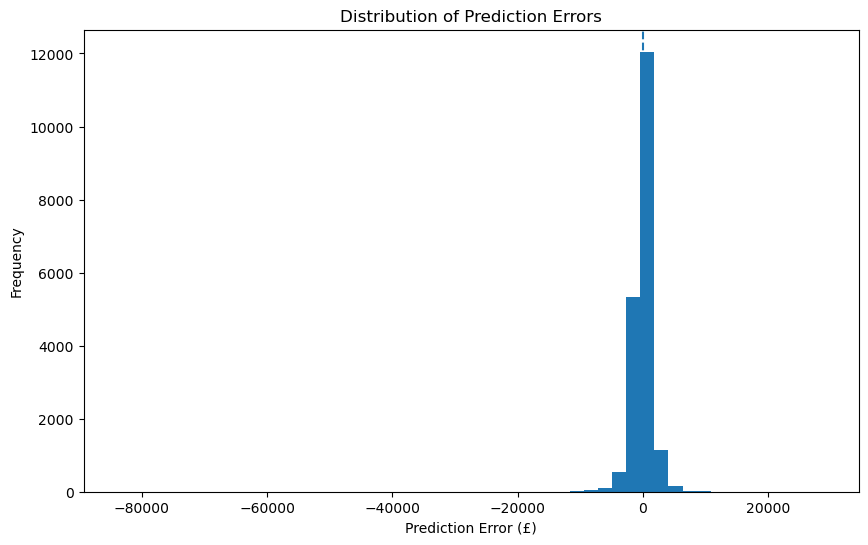

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(results["Error"], bins=50)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (£)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [71]:
import joblib

final_model = xgb_random_search_2.best_estimator_

joblib.dump(final_model, "../models/car_price_model.pkl")

['../models/car_price_model.pkl']